# EEG Chaos Dynamics

This notebook explores EEG signals from the perspective of nonlinear dynamical systems.

Instead of analyzing frequency content alone, we investigate the geometric structure of neural activity in phase space.

Goals:

- Reconstruct EEG attractors using delay embedding
- Visualize phase-space trajectories
- Estimate signal entropy
- Estimate fractal dimension
- Relate neural dynamics to theories of consciousness and complexity

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import antropy as ant

In [2]:
sleep_raw = mne.io.read_raw_brainvision(
    "../data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr",
    preload=True
)

wake_raw = mne.io.read_raw_brainvision(
    "../data/raw/sleep_data/sub_23/eeg/sub-23_task-rest_run-1_eeg.vhdr",
    preload=True
)

Extracting parameters from ../data/raw/sleep_data/sub_23/eeg/sub-23_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4601199  =      0.000 ...   920.240 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13552\136532330.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  sleep_raw = mne.io.read_raw_brainvision(


Extracting parameters from ../data/raw/sleep_data/sub_23/eeg/sub-23_task-rest_run-1_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 3307399  =      0.000 ...   661.480 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13552\136532330.py:6: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  wake_raw = mne.io.read_raw_brainvision(


In [3]:
sleep_raw.set_channel_types(
    {
        ch: "eeg"
        for ch in sleep_raw.ch_names
        if ch not in ["EOG", "ECG"]
    }
)

wake_raw.set_channel_types(
    {
        ch: "eeg"
        for ch in wake_raw.ch_names
        if ch not in ["EOG", "ECG"]
    }
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13552\1138363480.py:1: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  sleep_raw.set_channel_types(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13552\1138363480.py:9: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  wake_raw.set_channel_types(


<RawBrainVision | sub-23_task-rest_run-1_eeg.eeg, 32 x 3307400 (661.5 s), ~807.5 MiB, data loaded>

In [4]:
sleep_filtered = sleep_raw.copy().filter(
    0.5,
    45,
    picks="eeg"
)

wake_filtered = wake_raw.copy().filter(
    0.5,
    45,
    picks="eeg"
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 33001 samples (6.600 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband e

## Phase Space Reconstruction

A dynamical system can be visualized in phase space.

For EEG, we reconstruct an approximate phase space using delay embedding:

x(t), x(t + τ)

where τ is a time delay.

The resulting trajectory can reveal whether neural activity is highly regular, random, or exhibits complex nonlinear structure.

In [5]:
sleep_signal = sleep_filtered.get_data(
    picks=["Cz"]
)[0]

In [6]:
tau = 10

x = sleep_signal[:-tau]
y = sleep_signal[tau:]

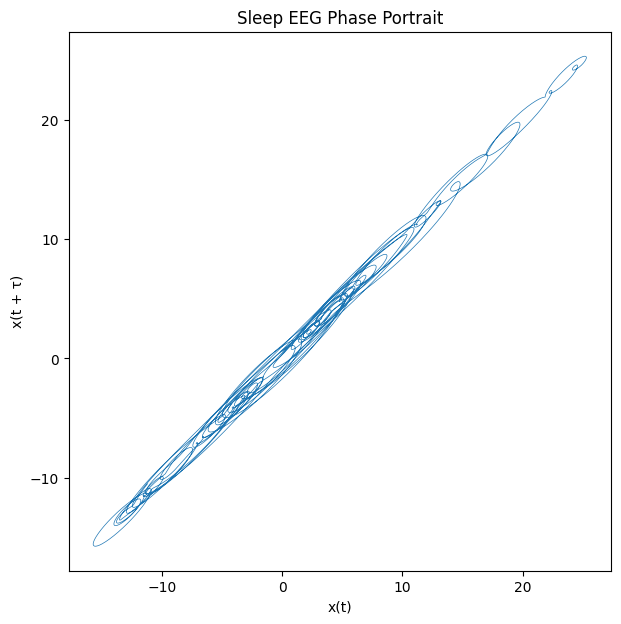

In [7]:
plt.figure(figsize=(7,7))

plt.plot(
    x[:10000],
    y[:10000],
    linewidth=0.5
)

plt.xlabel("x(t)")
plt.ylabel("x(t + τ)")
plt.title("Sleep EEG Phase Portrait")

plt.show()

In [8]:
wake_signal = wake_filtered.get_data(
    picks=["Cz"]
)[0]

tau = 10

x = wake_signal[:-tau]
y = wake_signal[tau:]

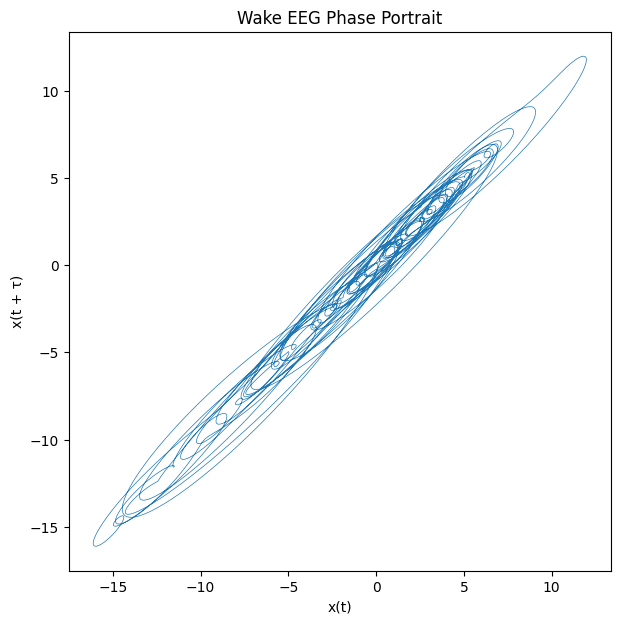

In [9]:
plt.figure(figsize=(7,7))

plt.plot(
    x[:10000],
    y[:10000],
    linewidth=0.5
)

plt.xlabel("x(t)")
plt.ylabel("x(t + τ)")
plt.title("Wake EEG Phase Portrait")

plt.show()

In [17]:
tau = 100

x = sleep_signal[:-2*tau]
y = sleep_signal[tau:-tau]
z = sleep_signal[2*tau:]

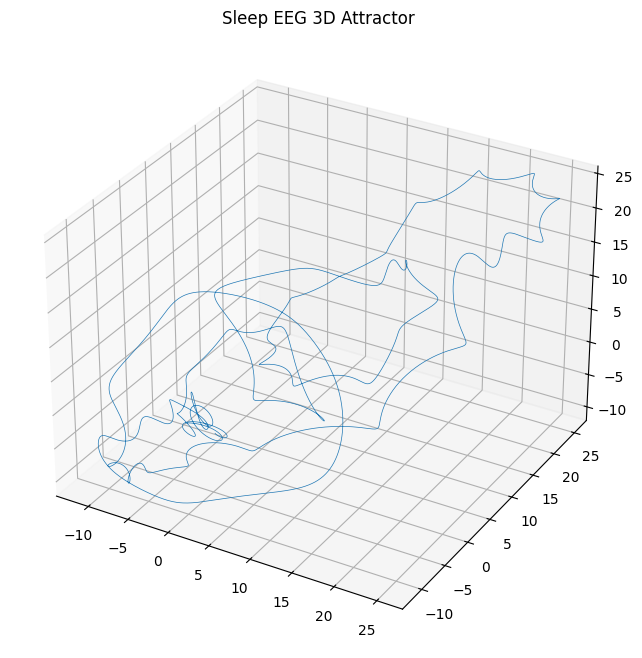

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot(
    x[:5000],
    y[:5000],
    z[:5000],
    linewidth=0.5
)

plt.title("Sleep EEG 3D Attractor")

plt.show()

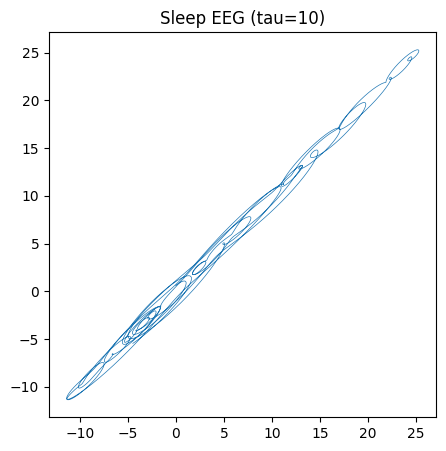

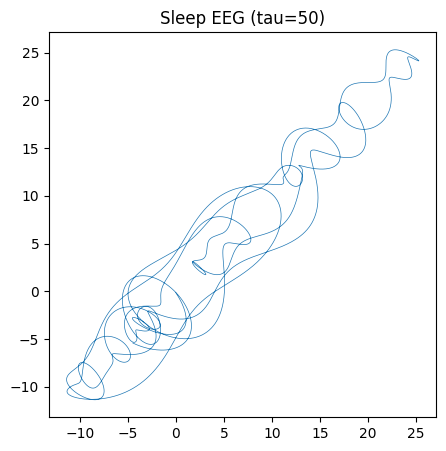

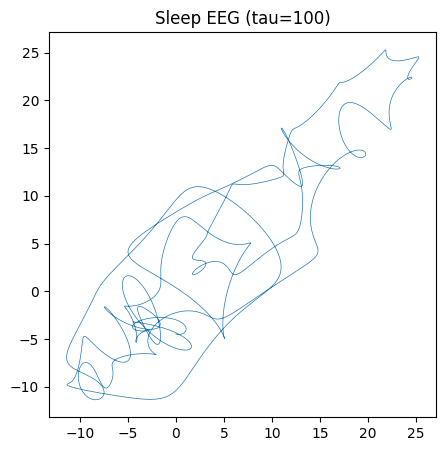

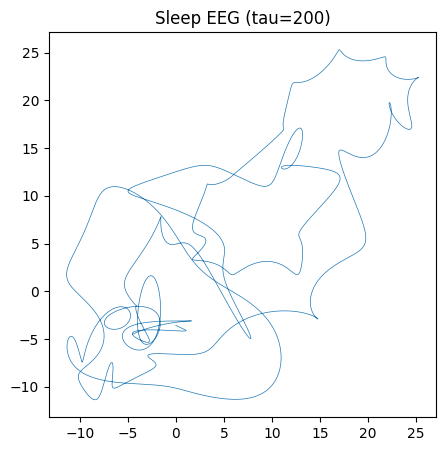

In [19]:
for tau in [10, 50, 100, 200]:
    
    x = sleep_signal[:-tau]
    y = sleep_signal[tau:]

    plt.figure(figsize=(5,5))

    plt.plot(
        x[:5000],
        y[:5000],
        linewidth=0.5
    )

    plt.title(f"Sleep EEG (tau={tau})")

    plt.show()

## Sample Entropy

Entropy quantifies signal unpredictability.

Higher entropy indicates richer and less predictable dynamics.

Lower entropy suggests more regular and repetitive activity.

In [10]:
sleep_entropy = ant.sample_entropy(
    sleep_signal[:10000]
)

print(
    "Sleep entropy:",
    sleep_entropy
)

Sleep entropy: 0.01760626377517719


In [11]:
wake_entropy = ant.sample_entropy(
    wake_signal[:10000]
)

print(
    "Wake entropy:",
    wake_entropy
)

Wake entropy: 0.035119966915004096


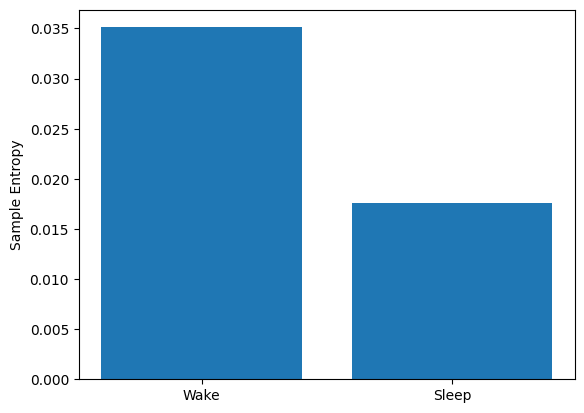

In [12]:
plt.bar(
    ["Wake","Sleep"],
    [wake_entropy, sleep_entropy]
)

plt.ylabel("Sample Entropy")

plt.show()

## Fractal Dimension

Fractal dimension measures geometric complexity.

Higher values indicate richer and more intricate signal structure.

In neuroscience, fractal properties have been linked to conscious processing and information integration.

In [13]:
sleep_fd = ant.higuchi_fd(
    sleep_signal[:10000]
)

print(
    "Sleep FD:",
    sleep_fd
)

Sleep FD: 1.0016020924956628


In [14]:
wake_fd = ant.higuchi_fd(
    wake_signal[:10000]
)

print(
    "Wake FD:",
    wake_fd
)

Wake FD: 1.0020592255441856


## Chaos Theory Perspective

The brain can be viewed as a complex dynamical system operating between order and randomness.

If neural activity becomes too ordered, information processing capacity decreases.

If neural activity becomes completely random, coherent cognition also breaks down.

Conscious states are therefore hypothesized to exist near a critical regime balancing stability and flexibility.

Measures such as entropy, fractal dimension, and attractor geometry provide complementary descriptions of this balance.

# Conclusions

This notebook explored EEG activity using concepts from nonlinear dynamics and chaos theory.

Key observations:

- EEG trajectories formed structured attractor-like patterns in phase space.
- Entropy quantified signal unpredictability.
- Fractal dimension quantified geometric complexity.
- Wakefulness and sleep exhibited different dynamical signatures.

These results support the idea that changes in consciousness can be studied not only through spectral analysis but also through the geometry and complexity of neural dynamics.